In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
df=pd.read_csv("readmitted.csv")

In [31]:
df

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,10499,85,Male,23.2,249,136.4,0.84,126,102,0,0,1,0.54,Medium,9.1,1
2996,10747,70,Male,26.1,125,139.4,0.71,135,82,0,1,1,0.57,Medium,47.6,0
2997,11948,69,Male,30.0,362,134.2,1.95,148,61,0,0,1,0.99,Medium,31.7,1
2998,12148,90,Female,26.2,503,143.6,0.16,145,56,1,1,0,0.61,Low,39.0,1


In [32]:
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [33]:
df.shape

(3000, 16)

In [34]:
numerical_cols=["age","bmi","bnp","creatinine","systolic_bp","heart_rate","adherence_score","distance_to_hospital_km"]

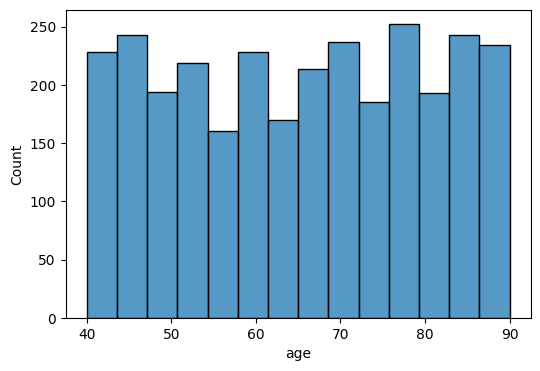

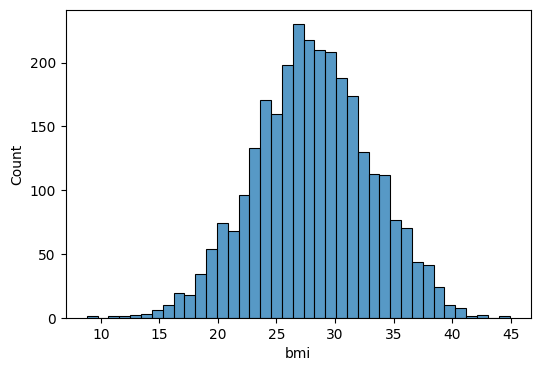

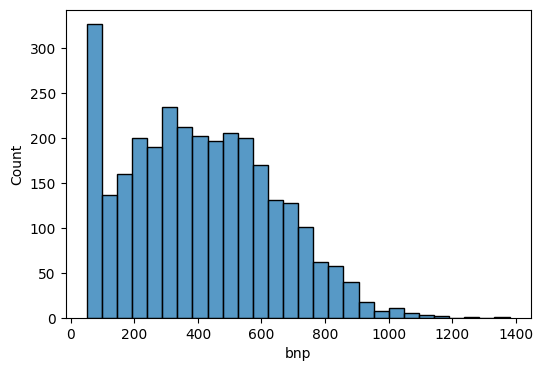

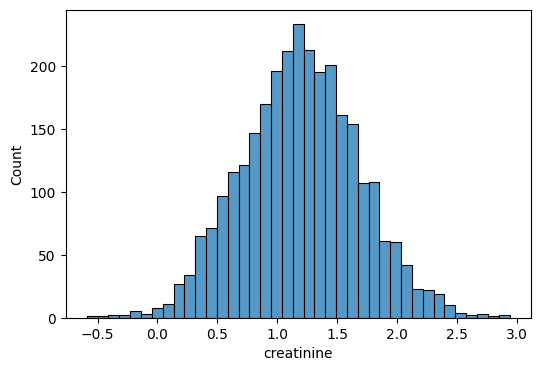

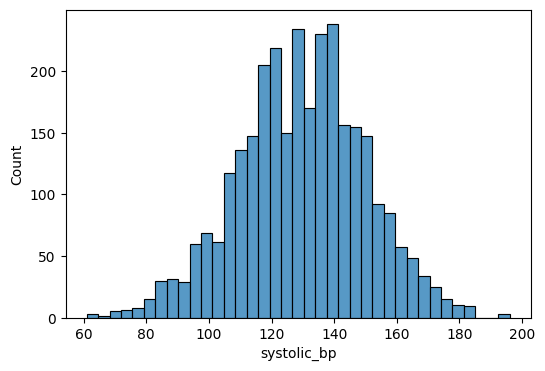

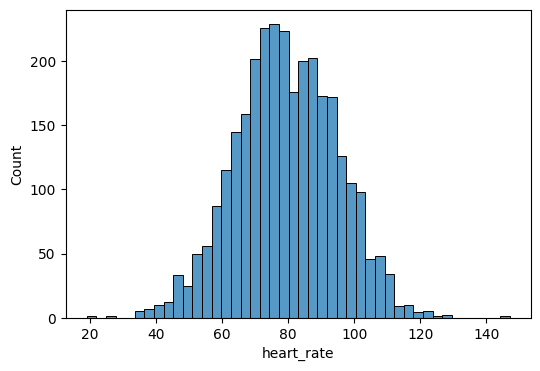

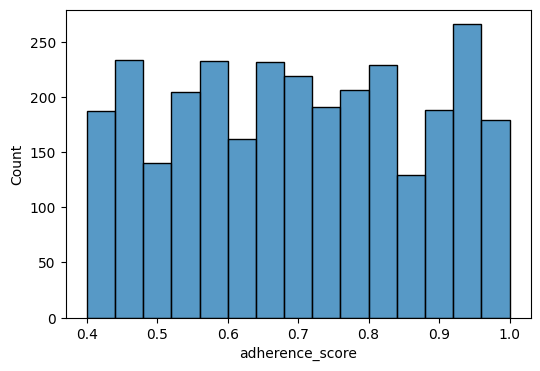

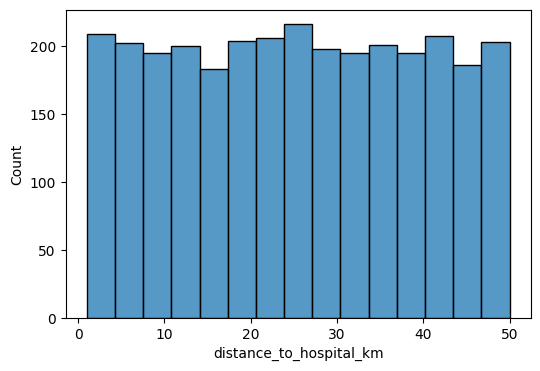

In [35]:
for t in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[t])

In [36]:
categorical_cols=["gender","ace_inhibitor",	"beta_blocker",	"diuretic","readmitted_30d","income_level"]

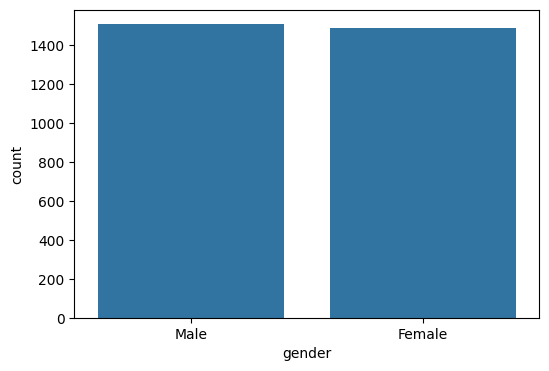

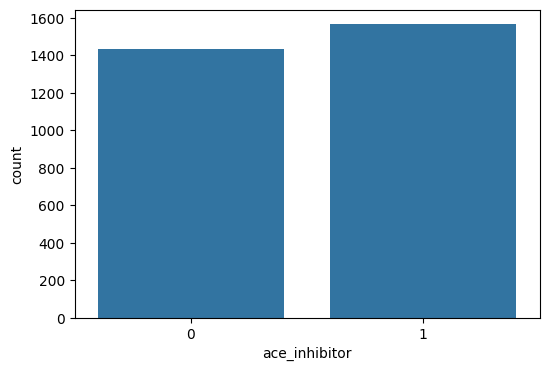

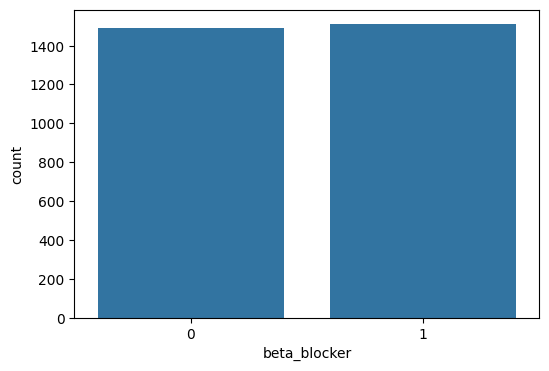

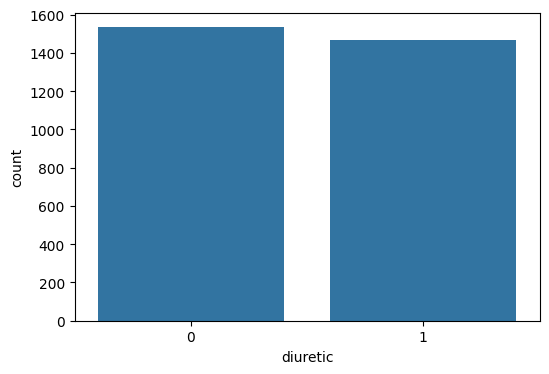

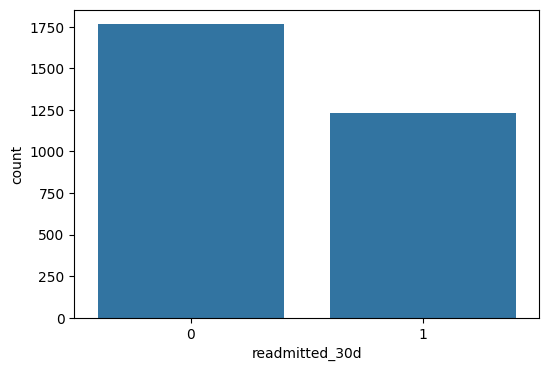

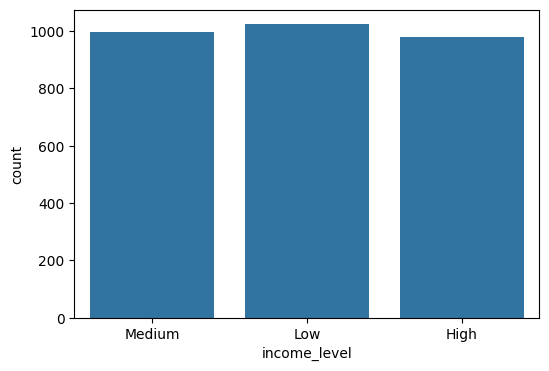

In [37]:
for p in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[p])

In [38]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,90
bnp,0
sodium,90
creatinine,90
systolic_bp,0
heart_rate,0
ace_inhibitor,0


In [39]:
df[["bmi","sodium","creatinine"]]=df[["bmi","sodium","creatinine"]].fillna(df[["bmi","sodium","creatinine"]].mean())

In [40]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,0
bnp,0
sodium,0
creatinine,0
systolic_bp,0
heart_rate,0
ace_inhibitor,0


In [41]:
df=pd.get_dummies(df,columns=["gender","income_level"],drop_first=True,dtype=int)

In [42]:
df.head()

,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,12911,76,23.9,738,135.30000,1.58,151,93,1,1,0,0.98,12.4,0,1,0,1
1,12521,77,32.3,405,143.00000,1.50,107,74,1,0,1,0.66,38.8,1,1,0,1
2,10155,42,29.3,399,138.08921,1.43,121,97,1,0,1,0.93,43.5,1,1,1,0
3,12088,83,29.1,524,135.10000,0.91,114,66,0,1,1,0.54,33.3,1,0,1,0
4,10792,48,24.2,301,139.50000,0.54,122,79,1,1,1,0.78,21.3,0,0,0,0


In [43]:
final_df =df [[
    "age",
    "bmi",
    "bnp",
    "sodium",
    "creatinine",
    "systolic_bp",
    "heart_rate",
    "ace_inhibitor",
    "beta_blocker",
    "diuretic",
    "adherence_score",
    "distance_to_hospital_km",
    "readmitted_30d",
    "gender_Male",
    "income_level_Low",
    "income_level_Medium"
]]
final_df.head()

,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,76,23.9,738,135.30000,1.58,151,93,1,1,0,0.98,12.4,0,1,0,1
1,77,32.3,405,143.00000,1.50,107,74,1,0,1,0.66,38.8,1,1,0,1
2,42,29.3,399,138.08921,1.43,121,97,1,0,1,0.93,43.5,1,1,1,0
3,83,29.1,524,135.10000,0.91,114,66,0,1,1,0.54,33.3,1,0,1,0
4,48,24.2,301,139.50000,0.54,122,79,1,1,1,0.78,21.3,0,0,0,0


In [44]:
from sklearn.model_selection import train_test_split
X=final_df.drop("readmitted_30d",axis=1)
Y=final_df["readmitted_30d"]

In [45]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [46]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000, penalty = 'l2',  C = 1.0)
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
y_prob = model.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(Y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7062491126780559


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

print(cm)

[[296  78]
 [118 108]]


In [50]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75       374
           1       0.58      0.48      0.52       226

    accuracy                           0.67       600
   macro avg       0.65      0.63      0.64       600
weighted avg       0.66      0.67      0.67       600



In [51]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_30 = (y_prob >= 0.30).astype(int)



In [52]:
print(confusion_matrix(Y_test, y_pred_30))


[[125 249]
 [ 23 203]]


In [53]:
print(classification_report(Y_test, y_pred_30))

              precision    recall  f1-score   support

           0       0.84      0.33      0.48       374
           1       0.45      0.90      0.60       226

    accuracy                           0.55       600
   macro avg       0.65      0.62      0.54       600
weighted avg       0.70      0.55      0.52       600

